# Online Advertisement Evaluation for TVs

Let's evaluate some online ads options to pick the best one.

In [2]:
import json
import sys
sys.path.insert(0, '..')
import os
# APIキーの設定（環境変数 OPENAI_API_KEY を事前に設定してください）
assert os.environ.get("OPENAI_API_KEY"), "環境変数 OPENAI_API_KEY が設定されていません"

import matplotlib.pyplot as plt

import tinytroupe
from tinytroupe.agent import TinyPerson
from tinytroupe.environment import TinyWorld
from tinytroupe.examples import create_lisa_the_data_scientist, create_oscar_the_architect
from tinytroupe.factory import TinyPersonFactory

from tinytroupe.extraction import ResultsExtractor


!!!!
DISCLAIMER: TinyTroupe relies on Artificial Intelligence (AI) models to generate content. 
The AI models are not perfect and may produce inappropriate or inacurate results. 
For any serious or consequential use, please review the generated content before using it.
!!!!

Looking for default config on: /Users/haruto/Projects/TinyTroupe_Tutorial/examples/../tinytroupe/utils/../config.ini
Found custom config on: /Users/haruto/Projects/TinyTroupe_Tutorial/examples/config.ini
TinyTroupe version: 0.5.2
Current date and time (local): 2025-11-05 04:54:22
Current date and time (UTC):   2025-11-04 19:54:22

Current TinyTroupe configuration 
[OpenAI]
api_type = openai
azure_api_version = 2024-08-01-preview
model = gpt-4.1-mini
reasoning_model = o3-mini
embedding_model = text-embedding-3-small
max_tokens = 32000
temperature = 1.5
freq_penalty = 0.1
presence_penalty = 0.1
timeout = 480
max_attempts = 5
waiting_time = 0
exponential_backoff_factor = 5
reasoning_effort = high
cache_api_calls = Fa

/opt/anaconda3/envs/tinytroupe/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'validate_default' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'validate_default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(


## Judging the best ad

Consider the following ads, obtained from real Bing queries.

In [3]:
# User search query: "55 inches tv"

# Ad targeting tech enthusiasts
tv_ad_1 =\
"""
The Ultimate Gaming Experience - LG 4K Ultra HD TV
https://www.lg.com/tv/oled
AdExperience Next-Level Gaming with LG's 4K OLED TV. Unmatched Picture Quality and Ultra-Fast Response Time. Perfect for Gamers and Tech Enthusiasts.

Infinite Contrast · Self-Lighting OLED · Dolby Vision™ IQ · ThinQ AI w/ Magic Remote

Exclusive Gaming Features
LG G2 97" OLED evo TV
Free Gaming Stand w/ Purchase
World's No.1 OLED TV
"""

# Ad targeting families
tv_ad_2 =\
"""
The Perfect Family TV - Samsung 4K & 8K TVs
https://www.samsung.com
AdBring Your Family Together with Samsung's 4K & 8K TVs. Stunning Picture Quality and Family-Friendly Features. Ideal for Movie Nights and Family Gatherings.

Discover Samsung Event · Real Depth Enhancer · Anti-Reflection · 48 mo 0% APR Financing

The 2023 OLED TV Is Here
Samsung Neo QLED 4K TVs
Samsung Financing
Ranked #1 By The ACSI®

Perfect for Family Movie Nights
"""

# Ad targeting budget-conscious shoppers
tv_ad_3 =\
"""
Affordable 55 Inch TV - Wayfair Deals
Shop Now
https://www.wayfair.com/furniture/free-shipping
AdGet the Best Deals on 55 Inch TVs at Wayfair. High-Quality TVs at Budget-Friendly Prices. Free Shipping on All Orders Over $35.

Affordable Prices · Great Deals · Free Shipping
"""

Let's build a request for our agents to pick the best ad.

In [4]:
eval_request_msg = \
f"""
Can you evaluate these Bing ads for me? Which one convices you more to buy their particular offering? 
Select **ONLY** one. Please explain your reasoning, based on your financial situation, background and personality.

# AD 1
```
{tv_ad_1}
```

# AD 2
```
{tv_ad_2}
```

# AD 3
```
{tv_ad_3}
```
"""

print(eval_request_msg)


Can you evaluate these Bing ads for me? Which one convices you more to buy their particular offering? 
Select **ONLY** one. Please explain your reasoning, based on your financial situation, background and personality.

# AD 1
```

The Ultimate Gaming Experience - LG 4K Ultra HD TV
https://www.lg.com/tv/oled
AdExperience Next-Level Gaming with LG's 4K OLED TV. Unmatched Picture Quality and Ultra-Fast Response Time. Perfect for Gamers and Tech Enthusiasts.

Infinite Contrast · Self-Lighting OLED · Dolby Vision™ IQ · ThinQ AI w/ Magic Remote

Exclusive Gaming Features
LG G2 97" OLED evo TV
Free Gaming Stand w/ Purchase
World's No.1 OLED TV

```

# AD 2
```

The Perfect Family TV - Samsung 4K & 8K TVs
https://www.samsung.com
AdBring Your Family Together with Samsung's 4K & 8K TVs. Stunning Picture Quality and Family-Friendly Features. Ideal for Movie Nights and Family Gatherings.

Discover Samsung Event · Real Depth Enhancer · Anti-Reflection · 48 mo 0% APR Financing

The 2023 OLED TV Is 

Let's also have a reason for them to require a new TV.

In [5]:
situation = "Your TV broke and you need a new one. You search for a new TV on Bing."

### Try with standard agents

To begin with, let's pick a pre-defined agent and ask him or her to perform the evaluations. To make it easier to change the chosen agent, we assign it to a variable first.

In [6]:
TinyPerson.all_agents

{}

In [7]:
lisa = create_lisa_the_data_scientist()

In [8]:
lisa.change_context(situation)

In [9]:
lisa.listen_and_act(eval_request_msg)

USER --> Lisa Carter: [CONVERSATION] 
          >  Can you evaluate these Bing ads for me? Which one convices you more to buy their
          > particular offering?  Select **ONLY** one. Please explain your reasoning, based on your
          > financial situation, background and personality.  # AD 1 ```  The Ultimate Gaming
          > Experience - LG 4K Ultra HD TV https://www.lg.com/tv/oled AdExperience Next-Level Gaming
          > with LG's 4K OLED TV. Unmatched Picture Quality and Ultra-Fast Response Time. Perfect
          > for Gamers and Tech Enthusiasts.  Infinite Contrast · Self-Lighting OLED · Dolby Vision™
          > IQ · ThinQ AI w/ Magic Remote  Exclusive Gaming Features LG G2 97" OLED evo TV Free
          > Gaming Stand w/ Purchase World's No.1 OLED TV  ```  # AD 2 ```  The Perfect Family TV -
          > Samsung 4K & 8K TVs https://www.samsung.com AdBring Your Family Together with Samsung's
          > 4K & 8K TVs. Stunning Picture Quality and Family-Friendly Features. Ideal for Movie
          > Nights and Family Gatherings.  Discover Samsung Event · Real Depth Enhancer · Anti-
          > Reflection · 48 mo 0% APR Financing  The 2023 OLED TV Is Here Samsung Neo QLED 4K (...)

Lisa Carter acts: [THINK] 
                 > I need to evaluate the three ads based on my financial situation, background, and
                 > personality. As a data scientist at Microsoft with a Master's in Data Science, I
                 > appreciate clear, well-documented information and value quality and reliability.
                 > I am curious and analytical, so I will consider the technical features and the
                 > appeal of each ad. Financially, I am likely to be middle-income, so affordability
                 > matters but I also value quality. The first ad emphasizes high-end gaming
                 > features and picture quality, which appeals to tech enthusiasts but might be
                 > expensive. The second ad focuses on family-friendly features and financing
                 > options, which could be practical. The third ad highlights affordability and free
                 > shipping, which is attractive for budget-conscious buyers. Given my personality
                 > traits and preferences, I would likely be more convinced by the second ad because
                 > it balances quality with family use and offers financing, making it more
                 > accessible. The first ad is appealing but probably too niche and expensive;
                 > (...)

Lisa Carter acts: [TALK] 
                 > After considering the three ads, I find the Samsung ad most convincing. It offers
                 > a balance between quality and practicality, highlighting family-friendly features
                 > and financing options, which makes it accessible and suitable for various needs.
                 > While the LG ad appeals to tech enthusiasts like me with its advanced gaming
                 > features, it might be too specialized and costly. The Wayfair ad is budget-
                 > friendly but lacks the advanced features I value. So, Samsung's ad aligns best
                 > with my background, financial situation, and personality.

Lisa Carter acts: [DONE] 

Let's extract from the agent's interaction the best ad chosen. In this manner, we can easily process results later.

In [10]:
extractor = ResultsExtractor()

extraction_objective="Find the ad the agent chose. Extract the Ad number and title."

res = extractor.extract_results_from_agent(lisa, 
                          extraction_objective=extraction_objective,
                          situation=situation,
                          fields=["ad_number", "ad_title"],
                          verbose=True)

res

Extraction raw result message: {'content': '{"ad_number": 2, "ad_title": "The Perfect Family TV - Samsung 4K & 8K TVs"}', 'refusal': None, 'role': 'assistant', 'annotations': []}


{'ad_number': 2, 'ad_title': 'The Perfect Family TV - Samsung 4K & 8K TVs'}

We can then easily get the ad number and title from the results:

In [11]:
f"{res['ad_number']}: {res['ad_title']}"

'2: The Perfect Family TV - Samsung 4K & 8K TVs'

### Try with agents generated on the fly too

We don't really need to spend a lot of time customizing agents. We can create them on the fly from simple descriptions.

In [12]:
population_size = 30

In [13]:
factory = TinyPersonFactory.create_factory_from_demography("./information/populations/usa.json", 
                                                           population_size=population_size,
                                                           context=situation)

In [14]:
people = factory.generate_people(population_size, verbose=True)

In [15]:
target_audience = TinyWorld(f"Target audience", people, broadcast_if_no_target=False)
target_audience.broadcast(eval_request_msg)
target_audience.run(1, parallelize=False)


USER --> Eleanor Winslow-Merrick: [CONVERSATION] 
          >  Can you evaluate these Bing ads for me? Which one convices you more to buy their
          > particular offering?  Select **ONLY** one. Please explain your reasoning, based on your
          > financial situation, background and personality.  # AD 1 ```  The Ultimate Gaming
          > Experience - LG 4K Ultra HD TV https://www.lg.com/tv/oled AdExperience Next-Level Gaming
          > with LG's 4K OLED TV. Unmatched Picture Quality and Ultra-Fast Response Time. Perfect
          > for Gamers and Tech Enthusiasts.  Infinite Contrast · Self-Lighting OLED · Dolby Vision™
          > IQ · ThinQ AI w/ Magic Remote  Exclusive Gaming Features LG G2 97" OLED evo TV Free
          > Gaming Stand w/ Purchase World's No.1 OLED TV  ```  # AD 2 ```  The Perfect Family TV -
          > Samsung 4K & 8K TVs https://www.samsung.com AdBring Your Family Together with Samsung's
          > 4K & 8K TVs. Stunning Picture Quality and Family-Friendly Features. Ideal for Movie
          > Nights and Family Gatherings.  Discover Samsung Event · Real Depth Enhancer · Anti-
          > Reflection · 48 mo 0% APR Financing  The 2023 OLED TV Is Here Samsung Neo QLED 4K (...)

       + --> Dorian Whitfield-McAllister

       + --> Marissa Caldwell-Brooks

       + --> ...others...

─────────────────────────────────────────── Target audience step 1 of 1 ───────────────────────────────────────────

...

Colton Merrick acts: [TALK] 
                    > I gotta say, the Samsung ad really speaks to me. It highlights family-friendly
                    > features and even offers 48 months of 0% APR financing, which makes it easier
                    > on the wallet. Given that I’m all about providing for my family without
                    > breaking the bank, this seems like the best fit. The LG’s gaming features are
                    > cool, but probably more than I need, and the Wayfair deal sounds budget-
                    > friendly but might not have the quality or reliability I look for. So yeah,
                    > Samsung’s the one I’d go for.

Colton Merrick acts: [DONE] 

Sienna Calderwood-Miles acts: [THINK] 
                             > I'm considering the three ads based on my financial situation,
                             > background, and personality. The first ad is for a high-end LG 4K
                             > OLED TV with gaming features, which appeals to my interest in tech
                             > and quality but might be expensive. The second ad is for Samsung TVs
                             > marketed as family-friendly with financing options, which is
                             > appealing but less aligned with my personal use since I live with
                             > roommates and not a traditional family setup. The third ad is for
                             > affordable 55-inch TVs from Wayfair, which fits a tighter budget and
                             > my price-conscious nature but might lack the advanced features I
                             > want. Given my preference for quality, smart home integration, and a
                             > moderate budget, I need to weigh the value versus cost carefully. I
                             > tend to avoid overpriced gadgets with minimal added value, so the LG
                             > might be too pricey despite its features. The Samsung ad's financing
                             > is attractive but the family focus doesn't resonate much with me. The
                             > Wayfair deal is budget-friendly but may not meet my quality standards
                             > or smart features (...)

Sienna Calderwood-Miles acts: [TALK] 
                             > Honestly, the Wayfair ad speaks to me the most. I'm all about getting
                             > good quality without breaking the bank, and that affordable 55-inch
                             > TV with free shipping fits my budget-conscious vibe. The LG one
                             > sounds amazing with all those gaming features, but it's probably way
                             > out of my price range right now. Samsung's family focus doesn't
                             > really click with my living situation either. So yeah, Wayfair wins
                             > for me because it balances price and practicality, which is super
                             > important when I'm juggling school, work, and freelance gigs.

Sienna Calderwood-Miles acts: [DONE] 

In [16]:
extractor = ResultsExtractor()
extraction_objective="Find the ad the agent chose. Extract the Ad number and title, as well as the justification the agent gave to choose that. Extract only ONE result."

choices =[]

for person in people:
    res = extractor.extract_results_from_agent(person,
                                    extraction_objective=extraction_objective,
                                    situation=situation,
                                    fields=["ad_number", "ad_title", "justification"],
                                    fields_hints={"ad_number": "Must be an integer, not a string."},
                                    verbose=True)

    choices.append(res)

Extraction raw result message: {'content': '{"ad_number": 3, "ad_title": "Affordable 55 Inch TV - Wayfair Deals Shop Now", "justification": "Considering my financial situation and personality, I find the third ad from Wayfair most convincing. It offers affordable 55 inch TVs with free shipping, which aligns well with my cautious spending habits and preference for straightforward, budget-friendly options. The first ad seems too high-end and targeted at gamers, which doesn\'t suit me, and the second ad focuses on family features, which is less relevant to my lifestyle. So, the third ad feels the most practical and appealing to me."}', 'refusal': None, 'role': 'assistant', 'annotations': []}
Extraction raw result message: {'content': '{"ad_number": 2, "ad_title": "The Perfect Family TV - Samsung 4K & 8K TVs", "justification": "It highlights family-friendly features and offers 48 months of 0% APR financing, which fits well with my goal of balancing quality and affordability for my family\'

In [17]:
choices

[{'ad_number': 3,
  'ad_title': 'Affordable 55 Inch TV - Wayfair Deals Shop Now',
  'justification': "Considering my financial situation and personality, I find the third ad from Wayfair most convincing. It offers affordable 55 inch TVs with free shipping, which aligns well with my cautious spending habits and preference for straightforward, budget-friendly options. The first ad seems too high-end and targeted at gamers, which doesn't suit me, and the second ad focuses on family features, which is less relevant to my lifestyle. So, the third ad feels the most practical and appealing to me."},
 {'ad_number': 2,
  'ad_title': 'The Perfect Family TV - Samsung 4K & 8K TVs',
  'justification': "It highlights family-friendly features and offers 48 months of 0% APR financing, which fits well with my goal of balancing quality and affordability for my family's needs. While the LG TV is impressive for gaming, it's not my main priority, and the Wayfair deal seems budget-friendly but might lack th

In [18]:
votes = {}
for choice in choices:
    print(f"{choice['ad_number']}: {choice['ad_title']}")

    ad_number = choice['ad_number']
    if ad_number not in votes:
        votes[ad_number] = 0
    votes[ad_number] += 1

3: Affordable 55 Inch TV - Wayfair Deals Shop Now
2: The Perfect Family TV - Samsung 4K & 8K TVs
3: Affordable 55 Inch TV - Wayfair Deals Shop Now
3: Affordable 55 Inch TV - Wayfair Deals Shop Now
3: Affordable 55 Inch TV - Wayfair Deals Shop Now
2: The Perfect Family TV - Samsung 4K & 8K TVs
2: The Perfect Family TV - Samsung 4K & 8K TVs
1: The Ultimate Gaming Experience - LG 4K Ultra HD TV
3: Affordable 55 Inch TV - Wayfair Deals Shop Now
2: The Perfect Family TV - Samsung 4K & 8K TVs
2: The Perfect Family TV - Samsung 4K & 8K TVs
3: Affordable 55 Inch TV - Wayfair Deals Shop Now
3: Affordable 55 Inch TV - Wayfair Deals Shop Now
3: Affordable 55 Inch TV - Wayfair Deals Shop Now
3: Affordable 55 Inch TV - Wayfair Deals Shop Now
1: The Ultimate Gaming Experience - LG 4K Ultra HD TV
2: The Perfect Family TV - Samsung 4K & 8K TVs
3: Affordable 55 Inch TV - Wayfair Deals Shop Now
2: The Perfect Family TV - Samsung 4K & 8K TVs
3: Affordable 55 Inch TV - Wayfair Deals Shop Now
2: The Perfec

In [19]:
votes

{3: 18, 2: 10, 1: 2}

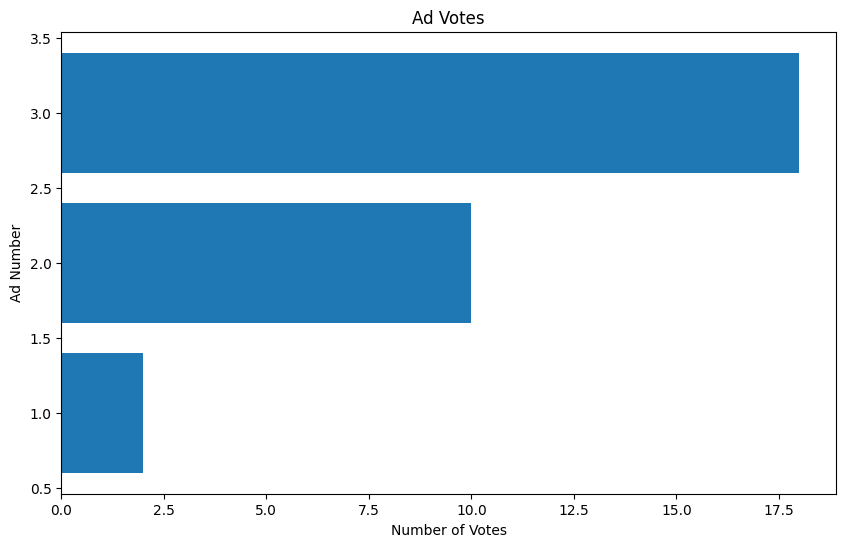

In [20]:
# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(list(votes.keys()), list(votes.values()))
# Add labels and title
plt.xlabel('Number of Votes')
plt.ylabel('Ad Number')
plt.title('Ad Votes')
# Show the plot
plt.show()


Finally, we pick the winner ad.

In [21]:
# picks the most voted ad
winner = max(votes, key=votes.get)
winner

3